In [1]:
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import WISEData, WISESample
from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample

from plotters import _savefig, plot_optical_vs_w2

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
def build_pl_arrays(data, mag_col, err_col):
    period = np.array(data["rrlyrae_representative_period"])
    period_err = np.array(data["rrlyrae_representative_period_error"])
    log_p = np.log10(period)
    sigma_logp = period_err / (period * np.log(10))
    return log_p - np.mean(log_p), np.array(data[mag_col]), np.array(data[err_col]), sigma_logp

In [3]:
data_path = Path("rrlyrae_calibration_sample.npz")
data = np.load(data_path, allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_optical = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_optical = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_optical_result = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrab_optical, "M_G", "sigma_M")))
rrc_optical_result = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrc_optical, "M_G", "sigma_M")))

Initializing NUTS using jitter+adapt_diag...
/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (

In [4]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
LEFT OUTER JOIN gaiadr3.allwise_best_neighbour AS bn
    ON vr.source_id = bn.source_id
LEFT OUTER JOIN gaiadr3.allwise_neighbourhood AS nh
    ON bn.source_id = nh.source_id
   AND bn.allwise_oid = nh.allwise_oid
LEFT OUTER JOIN gaiadr1.allwise_original_valid AS aw
    ON bn.allwise_oid = aw.allwise_oid
"""

wise_source = WISEData(query)
wise_filtered = WISESample(wise_source)

INFO: Query finished. [astroquery.utils.tap.core]


In [5]:
optical_ids = rrlyrae["source_id"]
wise_ids = wise_filtered.data["source_id"]
subset_ids = np.isin(wise_ids, optical_ids)
wise_data = wise_filtered.data[subset_ids]

rrab_infrared = wise_data[wise_data["best_classification"] == "RRab"]
rrc_infrared = wise_data[wise_data["best_classification"] == "RRc"]

rrab_infrared_result = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrab_infrared, "M_W2", "sigma_M_W2")))
rrc_infrared_result = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrc_infrared, "M_W2", "sigma_M_W2")))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


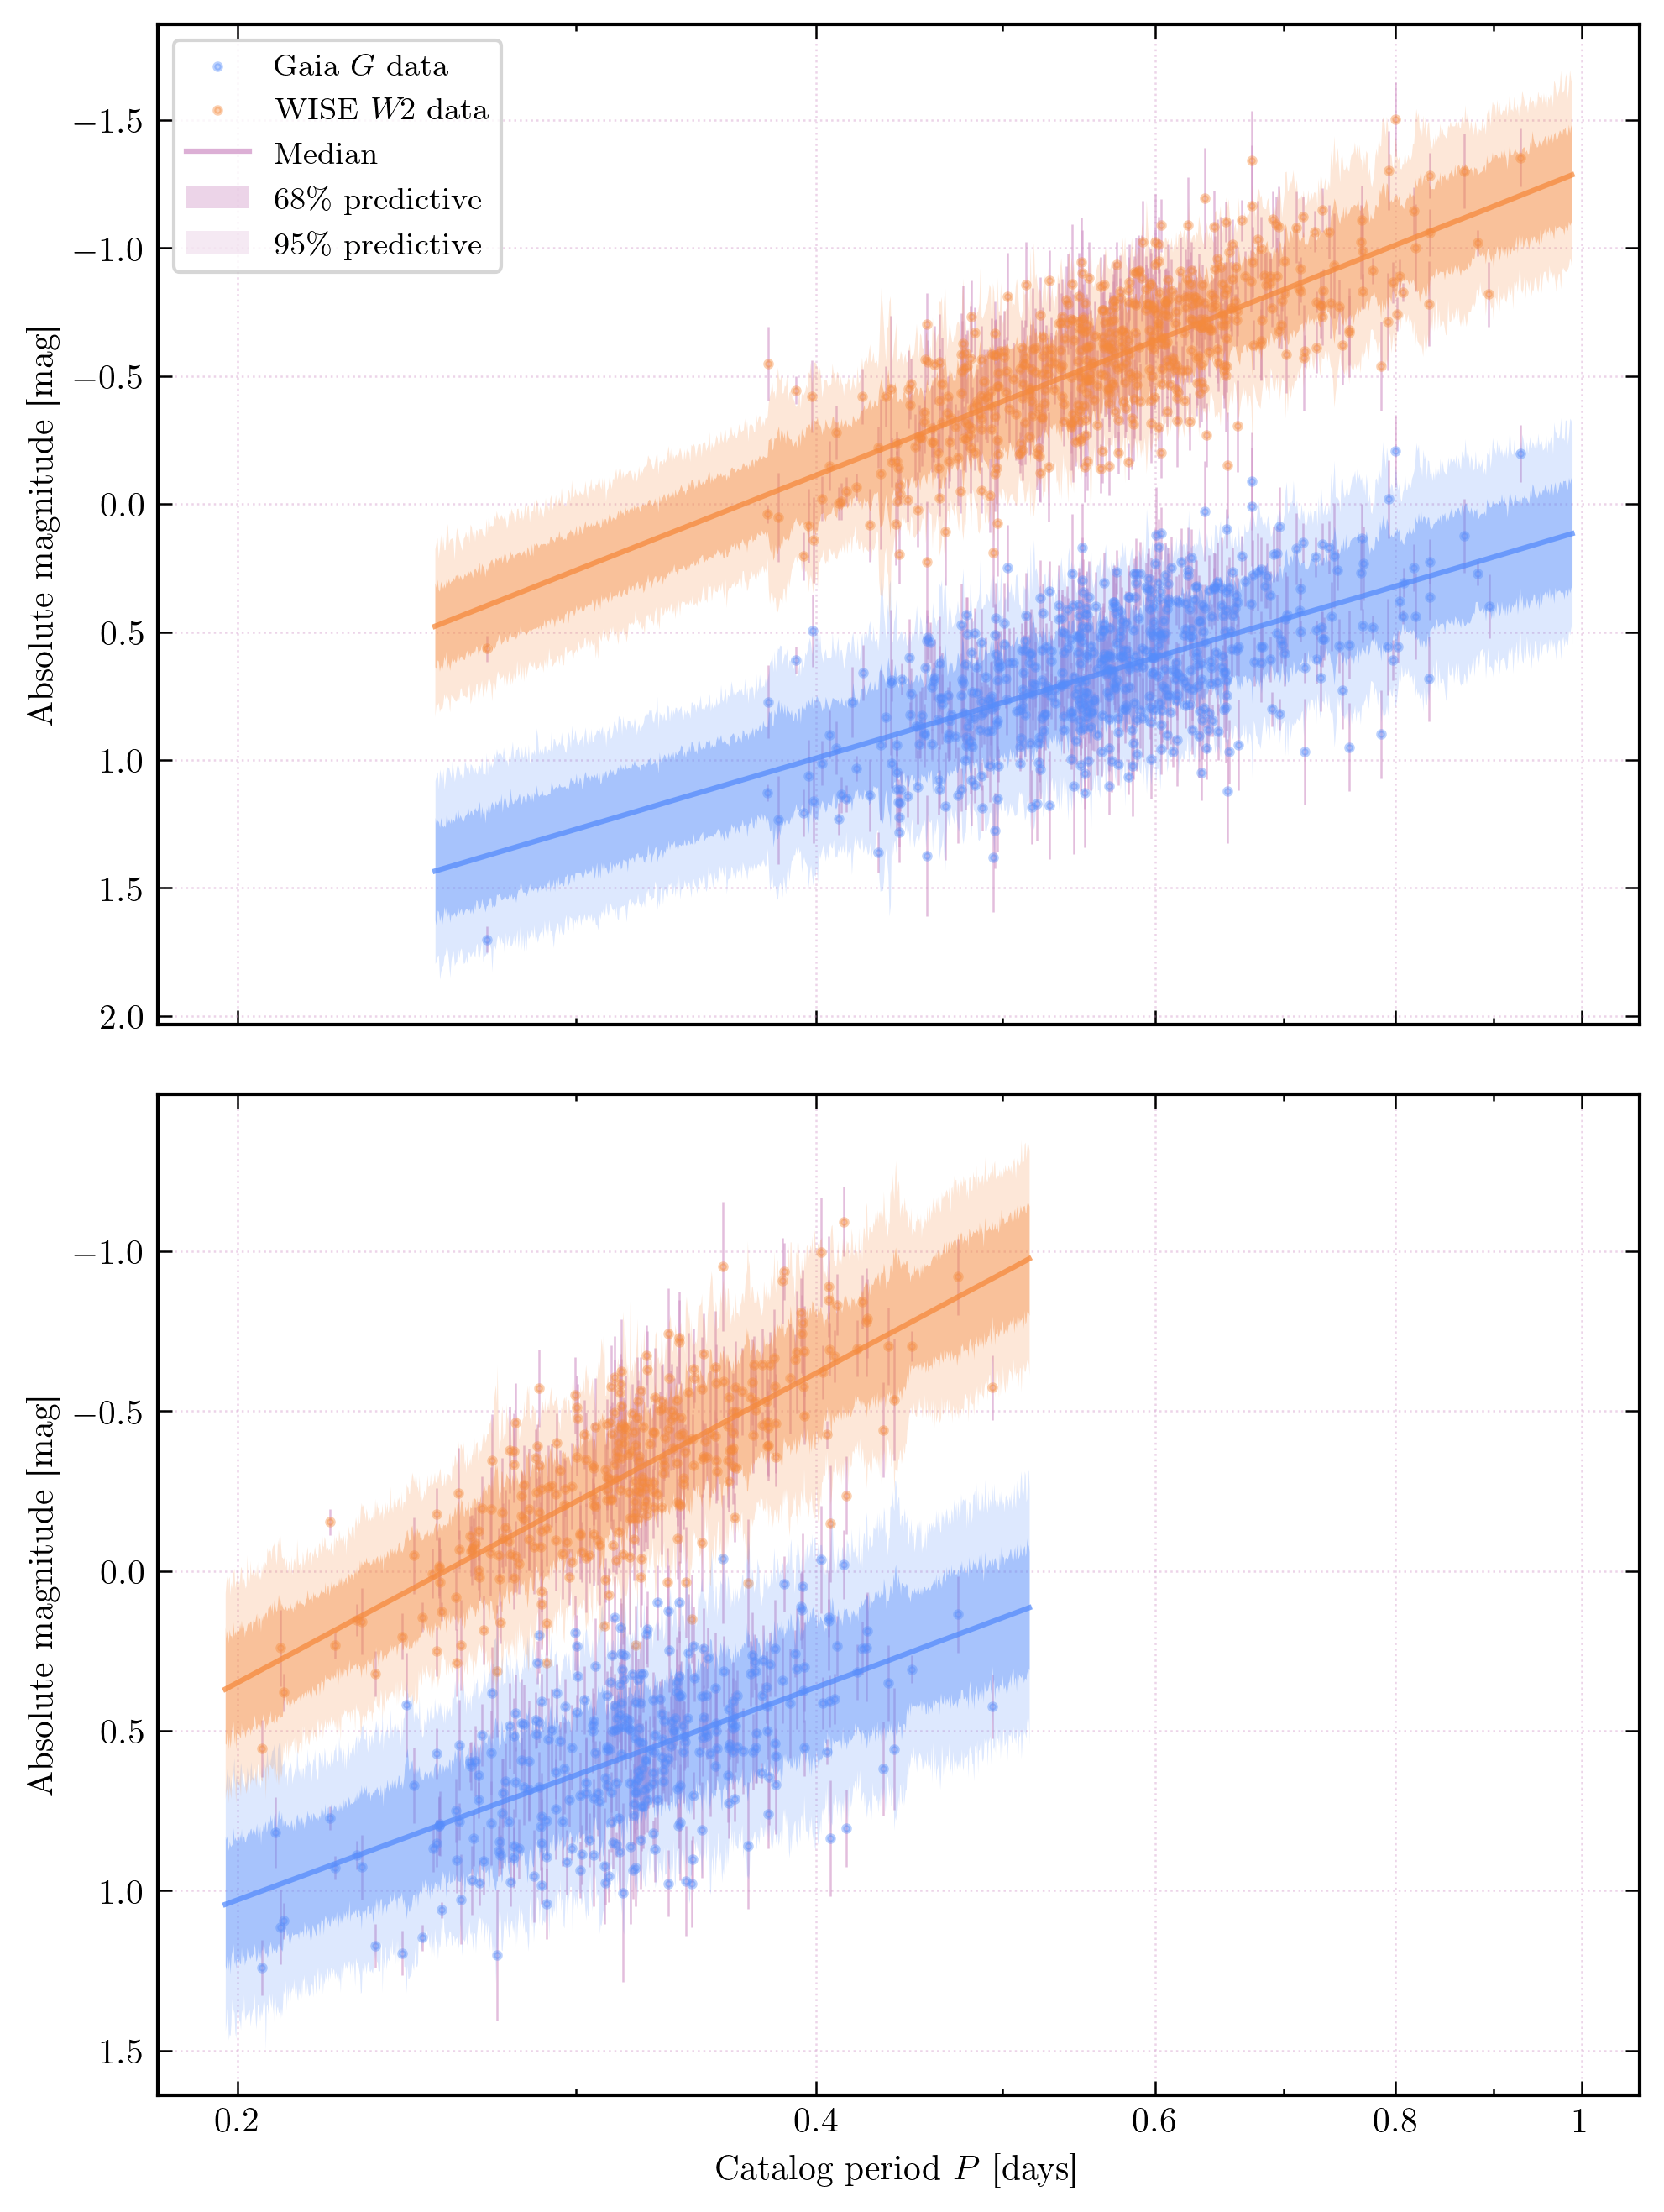

In [6]:
axes = plot_optical_vs_w2(
    rrab_optical_result, rrc_optical_result,
    rrab_infrared_result, rrc_infrared_result,
    float(np.mean(np.log10(rrab_optical["rrlyrae_representative_period"]))),
    float(np.mean(np.log10(rrc_optical["rrlyrae_representative_period"]))),
)
plt.show()